In [1]:
url1 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631" #only modified by block
url2 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=consil:ST_13940_2023_ADD_2_REV_1" #no modifies or modified by block
url3 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32019R2019" #both modifies or modified by block

In [ ]:
from graph_builder import GraphBuilder
import networkx as nx
import matplotlib.pyplot as plt

def graph(G):
    """
    Visualize the graph 
    """

    pos = nx.spring_layout(G, seed=50)
    edge_labels = {(u, v): d["relation"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_nodes(G, pos, node_size=10)
    nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                        arrowsize=20, connectionstyle="arc3,rad=0.1")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Directed Graph with Attributes")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [ ]:
# it takes 25s 
graph_data = GraphBuilder(url3)
modifiedby_data_list = graph_data.modifiedby_attributes_list
modifies_data_list = graph_data.modifies_attributes_list 
print(modifiedby_data_list) # should be [] in url2; shouldn't be [] in url1 and url3 
print(modifies_data_list) # should be [] in url1 and url2; shouldn't be [] in url3

[{'Relation': 'Corrected by', 'Act': '32019R2019R(01)', 'Comment': '(DA, DE, NL)', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Corrected by', 'Act': '32019R2019R(02)', 'Comment': '(PL)', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Corrected by', 'Act': '32019R2019R(03)', 'Comment': '(SL)', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Corrected by', 'Act': '32019R2019R(04)', 'Comment': '(FR)', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Corrected by', 'Act': '32019R2019R(05)', 'Comment': '(PL)', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Modified by', 'Act': '32021R0341', 'Comment': 'Replacement', 'Subdivision concerned': 'annex IV point 2 point (d)', 'From': '01/05/2021', 'To': ''}, {'Relation': 'Modified by', 'Act': '32021R0341', 'Comment': 'Addition', 'Subdivision concerned': 'annex III unnumbered paragraph 1 unnumbered paragraph', 'From': '01/05/2021', 'To': ''}, {'Relation'

In [13]:
# generate one modifiedby graph or one modifies graph by calling 
#subselect_modifiedby_attributes(self, relations=[], acts=[], comments=[], subdivisions=[], froms=[], tos=[])
#subselect_modifies_attributes(self, relations=[], acts=[], comments=[], subdivisions=[], froms=[], tos=[])
set_to_modifiedby = graph_data.subselect_modifiedby_attributes()
modifiedby_graph = graph_data.create_graph() # modifiedby graph 


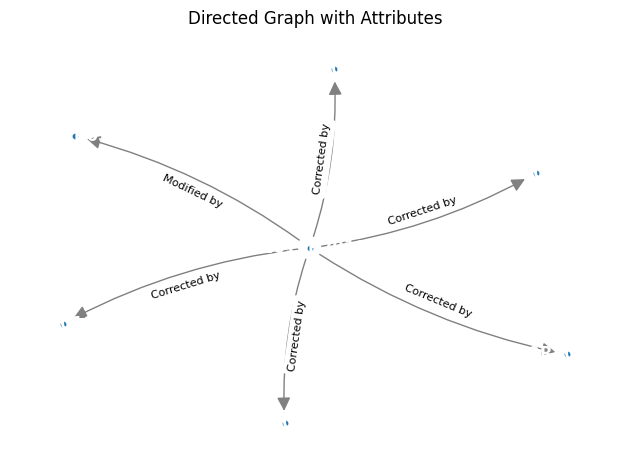

In [14]:
graph(modifiedby_graph);

In [15]:
set_to_modifies = graph_data.subselect_modifies_attributes()
modifies_graph = graph_data.create_graph()


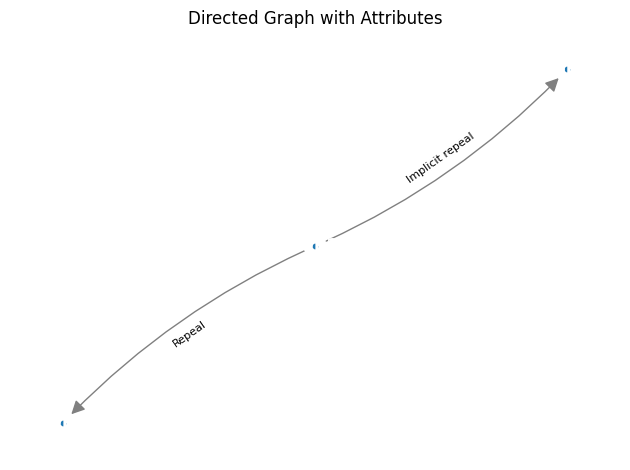

In [16]:
graph(modifies_graph);